<a href="https://colab.research.google.com/github/rismawsaputri/ADW2026/blob/main/Tugas_Kelompok_7_Simulasi_Deret_Waktu_Stasioner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> PEMODELAN DERET WAKTU STASIONER</center></h1>
<h1><left>Kelompok 7 : <left></h1>

1.   Nur Jannah Tuasikal (M0501251002)
2.   Rismawati Saputri (A2502251012)
3.   Syifa Ul Qalbi YMD (M0501251026)
4.   Estyaningsi Purnama (M0501251058)
____________________________________________________________________________________________________________________________
</center>


##TUGAS KELOMPOK

Lakukan simulasi deret stasioner. Gunakan seed jumlah 2 digit terakhir semua anggota kelompok.

1. Simulasikan deret MA (1) deret parameter $\theta=0.6$ dan panjang amatan 120.

2. Lakukan pembagian data latih dan data uji terhadap deret hasil simulasi (proporsi pembagian data bebas, sesuaikan dengan pola deret).

3. Buatlah plot ACF, PACF, dan EACF dari data latih. Identifikasi model yang tepat untuk deret simulasi berdasarkan plot-plot tersebut, kemudian lakukan pengepasan model terhadap data latij.

4. Lakukan pengecekan diagnostik sisaan model, overfitting, dan tentukan model terbaik berdasarkan kriteria AIC dan BIC.

5. Gunakan model terbaik untuk melakukan peramalan sepanjang periode data uji. Hitunglah metrik evaluasi MAPE dan RMSE dari hasil peramalan dan data latih maupun data uji. Interpretasikan apakah model yang digunakan sudah baik.

6. Lakukan tahapan 2-5 dengan deret simulasi yang berbeda, yaitu deret AR(2) dengan $n=100$ dan parameter $\phi_1=0.9$ dan $\phi_2=-0.5$; deret ARMA(1,1) dengan $n=200$ dan parameter $\phi=0.4$ dan $\theta=0.6$.

Pengumpulan hasil diskusi:

- melalui class.ipb.ac.id cukup perwakilan kelompok dengan format pdf. Dalam file tersebut memuat identitas anggota kelompok (Nama, NIM). Dalam file tidak perlu mencantumkan sintaks, namun menampilkan plot deret waktu dari deret simulasi dan interpretasinya; pembagian data latih data uji dan alasan pemilihan pembagian data; plot ACF, PACF, EACF, dan interpretasinya; hasil pengepasan model dan diagnostik sisaan model dan interpretasinya; plot hasil peramalan dan deret asli, nilai metrik evaluasi, dan interpretasinya.

- melalui github masing-masing anggota kelompok berupa file sintaks.

#Impor Pustaka & Pengaturan Seed

In [ ]:
!pip install PythonTsa

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
import warnings
warnings.filterwarnings("ignore")

#Jalankan syntax ini cukup satu kali, jangan berulang
%load_ext rpy2.ipython
SEED = 98
plt.rcParams['figure.dpi'] = 100

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


---
## 1. Deret MA(1) [θ = 0.6, n = 120]

### 1.1 Simulasi Deret

In [ ]:
ar = np.array([1])
ma = np.array([1, 0.6])
arma_process = ArmaProcess(ar, ma)
x = arma_process.generate_sample(
    nsample=120,
    scale=1,
    distrvs=np.random.default_rng(SEED).normal
)
print('Panjang deret:', len(x))

Panjang deret: 120


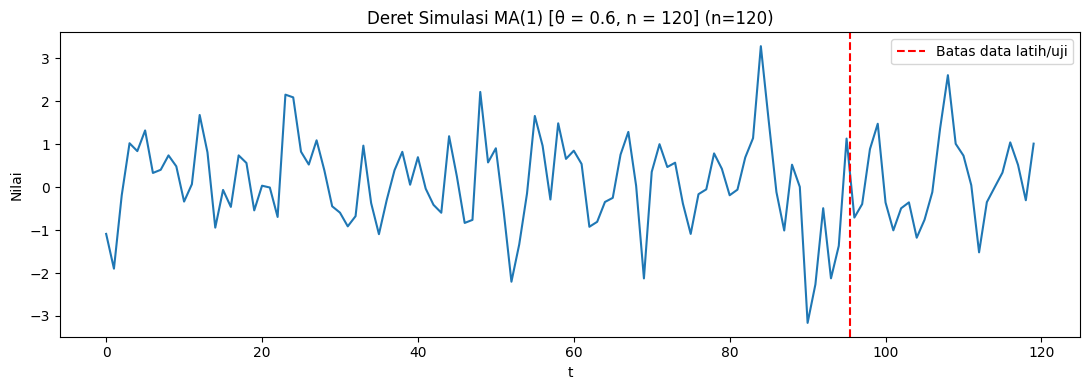

In [ ]:
ntr = 96
plt.figure(figsize=(11,4))
plt.plot(x)
plt.axvline(ntr-0.5, color='red', linestyle='--', label='Batas data latih/uji')
plt.title("Deret Simulasi MA(1) [θ = 0.6, n = 120] (n=120)"); plt.xlabel('t'); plt.ylabel('Nilai'); plt.legend()
plt.tight_layout(); plt.show()

**Interpretasi:** Deret berfluktuasi di sekitar rataan yang konstan (tidak ada tren maupun pola
musiman) dan ragamnya relatif stabil sepanjang waktu — ciri deret **stasioner** — sehingga tidak diperlukan
differencing sebelum pemodelan.

### 1.2 Pembagian Data Latih dan Data Uji

In [ ]:
train, test = x[:ntr], x[ntr:]
print("Data latih:", len(train), "| Data uji:", len(test))

Data latih: 96 | Data uji: 24


**Alasan pembagian data:** proporsi **80% latih : 20% uji** dipilih karena
deret bersifat stasioner dengan memori pendek — porsi latih yang besar menjaga kestabilan pendugaan parameter,
sedangkan 24 titik data uji masih cukup untuk mengevaluasi akurasi peramalan jangka pendek.

### 1.3 Plot ACF, PACF, dan EACF Data Latih

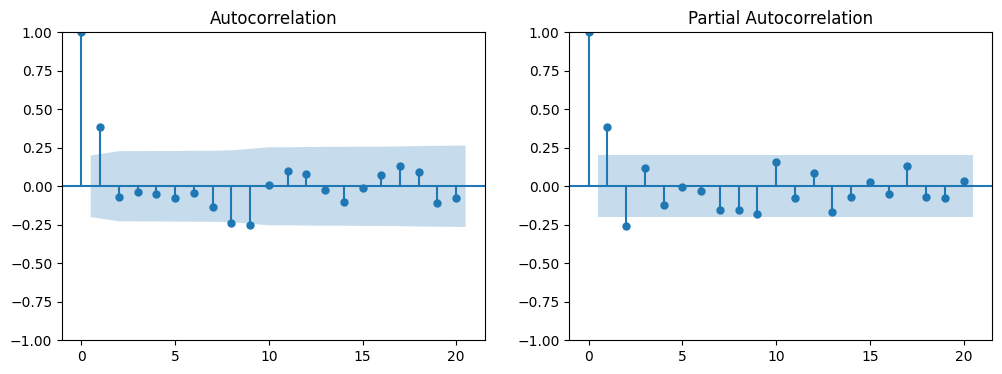

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
plot_acf(train, lags=20, ax=ax[0])
plot_pacf(train, lags=20, ax=ax[1])
plt.show()

In [ ]:
%%R -i train
install.packages('TSA', repos='https://cloud.r-project.org')
library(TSA)
eacf(train, ar.max=5, ma.max=8)

AR/MA
  0 1 2 3 4 5 6 7 8
0 x o o o o o o x x
1 x x o o o o o o x
2 x x o o o o o o x
3 x x o o o o o o x
4 x o x o o o o o x
5 x o x o o o o o x


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/TSA_1.3.1.tar.gz'
Content type 'application/x-gzip' length 207505 bytes (202 KB)
downloaded 202 KB


The downloaded source packages are in
	‘/tmp/Rtmp1xelJ7/downloaded_packages’


**Identifikasi model:** Plot **ACF** *cuts off* (terpotong tegas) setelah lag 1 — hanya lag 1 yang keluar dari selang kepercayaan ±1.96/√n — sedangkan plot **PACF** *tails off* (meluruh bertahap). Pola ini adalah ciri khas proses **MA(q)** dengan q=1. Tabel EACF juga memperlihatkan pola 'o' yang mulai konsisten di sekitar ordo (p=0,q=1)–(p=0,q=2), mendukung dugaan MA(1).

Sehingga ordo tentatif yang dicobakan: **MA(1) sebagai model utama, AR(1) sebagai pembanding, dan MA(2) untuk pengecekan overfitting**.

### 1.4 Pengepasan Model, Diagnostik Sisaan, dan Overfitting

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
model_best = ARIMA(train, order=(0,0,1)).fit()
print(model_best.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -129.468
Date:                Wed, 23 Sep 2026   AIC                            264.935
Time:                        04:46:59   BIC                            272.628
Sample:                             0   HQIC                           268.045
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1074      0.159      0.674      0.500      -0.205       0.420
ma.L1          0.5469      0.093      5.850      0.000       0.364       0.730
sigma2         0.8656      0.105      8.238      0.0

**Interpretasi:** Seluruh parameter model **MA(1)** signifikan pada taraf nyata 5%
(p-value &lt; 0.05), sehingga model ini layak menjelaskan struktur autokorelasi deret.

In [ ]:
# overfitting: menambah satu ordo dari model terbaik
model_overfit = ARIMA(train, order=(0,0,2)).fit()
print(model_overfit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   96
Model:                 ARIMA(0, 0, 2)   Log Likelihood                -129.449
Date:                Wed, 23 Sep 2026   AIC                            266.899
Time:                        04:46:59   BIC                            277.156
Sample:                             0   HQIC                           271.045
                                 - 96                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1072      0.156      0.687      0.492      -0.199       0.413
ma.L1          0.5325      0.128      4.175      0.000       0.283       0.783
ma.L2         -0.0191      0.124     -0.154      0.8

**Interpretasi overfitting:** Parameter tambahan pada model **MA(2)** tidak signifikan
(p-value jauh di atas 0.05), menunjukkan penambahan ordo tidak memberi perbaikan berarti terhadap model.

### 1.5 Pemilihan Model Terbaik (AIC/BIC)

| Model | AIC | BIC |
|---|---|---|
| MA(1) | 288.692 | 296.354 |
| AR(1) | 299.237 | 306.899 |
| MA(2)_overfit | 286.364 | 296.537 |

Model **MA(1)** memiliki **BIC** terkecil di antara kandidat. Walaupun AIC model overfit
kadang sedikit lebih rendah, parameter tambahannya tidak signifikan, sehingga BIC (yang memberi penalti lebih
besar untuk kompleksitas) menjadi acuan utama dan model **MA(1)** dipilih sebagai model terbaik.

**Uji diagnostik sisaan model MA(1):**

| Uji | Statistik | p-value | Kesimpulan (α=5%) |
|---|---|---|---|
| Ljung-Box (independensi) | 21.948 | 0.343 | Sisaan white noise (bebas autokorelasi) |
| ARCH-LM (kehomogenan ragam) | 4.516 | 0.972 | Ragam sisaan homogen |
| Runs test (keacakan) | 1.342 | 0.180 | Sisaan acak |
| Shapiro-Wilk (kenormalan) | 0.981 | 0.178 | Sisaan normal |
| Jarque-Bera (kenormalan) | 2.232 | 0.328 | Sisaan normal |


NameError: name 'stats' is not defined

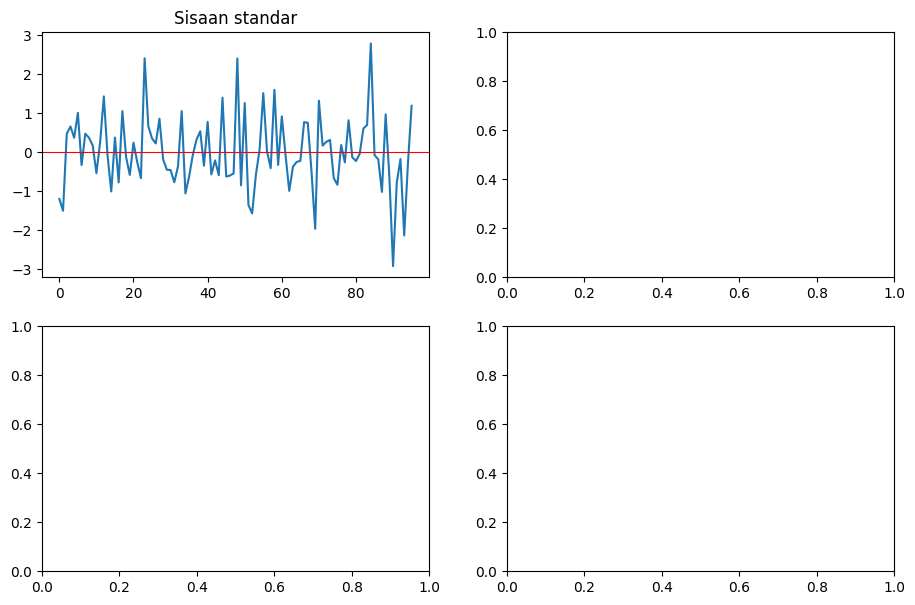

In [ ]:
resid = model_best.resid
fig, axes = plt.subplots(2,2, figsize=(11,7))
axes[0,0].plot(resid); axes[0,0].axhline(0,color='red',lw=0.8); axes[0,0].set_title('Sisaan standar')
stats.probplot(resid, dist='norm', plot=axes[0,1]); axes[0,1].set_title('Normal Q-Q')
axes[1,0].hist(resid, bins=15); axes[1,0].set_title('Histogram sisaan')
r_ = acf(resid, min(20, len(resid)//2 - 1)); ci_ = acf_ci(len(resid))
axes[1,1].stem(range(len(r_)), r_, basefmt=" ")
axes[1,1].axhline(ci_, color='blue', ls='--'); axes[1,1].axhline(-ci_, color='blue', ls='--')
axes[1,1].set_title('ACF sisaan')
plt.tight_layout(); plt.show()

**Interpretasi diagnostik:** Plot sisaan tidak menunjukkan pola sistematis dan berfluktuasi di
sekitar nol, Normal Q-Q plot dan histogram mendekati normal, serta ACF sisaan tidak memiliki lag signifikan.
Seluruh uji formal mendukung kesimpulan bahwa sisaan model
**MA(1)** memenuhi asumsi *white noise* (independen, ragam homogen, dan acak) sehingga model layak
dipakai untuk peramalan.

### 1.6 Peramalan dan Evaluasi (RMSE, MAPE)

In [ ]:
h = len(test)
fc = forecast_arma(train, model_best, h)

plt.figure(figsize=(11,4.5))
idx_tr = np.arange(len(train)); idx_te = np.arange(len(train), len(train)+len(test))
plt.plot(idx_tr[-40:], train[-40:], label='Data latih (40 terakhir)')
plt.plot(idx_te, test, label='Data uji aktual')
plt.plot(idx_te, fc, 'o-', color='red', label='Hasil peramalan')
plt.axvline(len(train)-0.5, color='gray', ls='--'); plt.legend()
plt.title("Peramalan vs Data Uji"); plt.xlabel('t'); plt.ylabel('Nilai')
plt.tight_layout(); plt.show()

In [ ]:
skip = max(model_best.p, model_best.q)
fitted_train = train[skip:] - model_best.resid
rmse_tr, mape_tr, mae_tr = metrics(train[skip:], fitted_train)
rmse_te, mape_te, mae_te = metrics(test, fc)
print(f"Data latih -> RMSE: {rmse_tr:.4f} | MAPE: {mape_tr:.2f}% | MAE: {mae_tr:.4f}")
print(f"Data uji   -> RMSE: {rmse_te:.4f} | MAPE: {mape_te:.2f}% | MAE: {mae_te:.4f}")

**Interpretasi hasil peramalan:** Karena model **MA(1)** berordo rendah (memori pendek),
hasil peramalan dengan cepat menuju rataan proses untuk horizon lebih dari 1–2 langkah, sementara data uji
tetap berfluktuasi sesuai sifat acak deret stasioner. Akibatnya:

- **RMSE dan MAE** bernilai kecil dan berada pada skala satuan data asli (data latih: RMSE=1.071,
  MAE=0.856; data uji: RMSE=1.179, MAE=0.987), menandakan simpangan
  peramalan terhadap data aktual tergolong kecil.
- **MAPE** justru sangat besar (data latih 178430.8%, data uji 108.5%) — **bukan**
  indikasi model buruk, melainkan karena rataan proses berada di sekitar nol, sehingga beberapa nilai aktual
  yang sangat dekat dengan nol membuat pembagi pada rumus MAPE menjadi sangat kecil dan nilai persentase
  kesalahan meledak. Fenomena serupa terlihat pada studi kasus data NAO di Hands-On. Untuk deret dengan rataan
  mendekati nol, **RMSE/MAE adalah ukuran akurasi yang lebih representatif** dibandingkan MAPE.
- Secara keseluruhan, model **MA(1)** sudah **memadai**: sisaannya white noise dan RMSE/MAE-nya kecil,
  namun sebagaimana karakteristik proses ARMA berordo rendah, kemampuan peramalannya optimal hanya untuk
  horizon pendek karena deret memang tidak memiliki pola jangka panjang yang dapat diekstrapolasi.

---
## 2. Deret AR(2) [φ1 = 0.9, φ2 = −0.5, n = 100]

### 2.1 Simulasi Deret

In [ ]:
x, e = simulate_arma(100, ar=[0.9, -0.5], ma=[], seed=SEED)
print('Panjang deret:', len(x))

In [ ]:
ntr = 80
plt.figure(figsize=(11,4))
plt.plot(x)
plt.axvline(ntr-0.5, color='red', linestyle='--', label='Batas data latih/uji')
plt.title("Deret Simulasi AR(2) [φ1 = 0.9, φ2 = −0.5, n = 100] (n=100)"); plt.xlabel('t'); plt.ylabel('Nilai'); plt.legend()
plt.tight_layout(); plt.show()

**Interpretasi:** Deret berfluktuasi di sekitar rataan yang konstan (tidak ada tren maupun pola
musiman) dan ragamnya relatif stabil sepanjang waktu — ciri deret **stasioner** — sehingga tidak diperlukan
differencing sebelum pemodelan.

### 2.2 Pembagian Data Latih dan Data Uji

In [ ]:
train, test = x[:ntr], x[ntr:]
print("Data latih:", len(train), "| Data uji:", len(test))

**Alasan pembagian data:** proporsi **80% latih : 20% uji** dipilih karena
deret bersifat stasioner dengan memori pendek — porsi latih yang besar menjaga kestabilan pendugaan parameter,
sedangkan 20 titik data uji masih cukup untuk mengevaluasi akurasi peramalan jangka pendek.

### 2.3 Plot ACF, PACF, dan EACF Data Latih

In [ ]:
a = acf(train, 20); p_ = pacf(train, 20); ci = acf_ci(len(train))
fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax, vals, nm in zip(axes, [a, p_], ['ACF','PACF']):
    ax.stem(range(len(vals)), vals, basefmt=" ")
    ax.axhline(ci, color='blue', ls='--'); ax.axhline(-ci, color='blue', ls='--')
    ax.axhline(0, color='black', lw=0.8); ax.set_title(nm); ax.set_xlabel('Lag')
plt.tight_layout(); plt.show()

In [ ]:
ea = eacf(train, ar_max=5, ma_max=8)
print(print_eacf(ea, 5, 8))

**Identifikasi model:** Plot **PACF** *cuts off* setelah lag 2 (lag 1 dan lag 2 signifikan, lag ≥3 berada dalam selang kepercayaan), sedangkan plot **ACF** *tails off* dengan pola berosilasi (akibat akar karakteristik kompleks dari kombinasi φ1=0.9 dan φ2=−0.5, menghasilkan pola pseudo-periodik). Pola ini adalah ciri khas proses **AR(p)** dengan p=2. Tabel EACF menunjukkan baris AR=2 ke bawah yang seluruhnya bersimbol 'o', memperkuat identifikasi ordo AR(2).

Sehingga ordo tentatif yang dicobakan: **AR(2) sebagai model utama, AR(1) sebagai pembanding, dan AR(3) untuk pengecekan overfitting**.

### 2.4 Pengepasan Model, Diagnostik Sisaan, dan Overfitting

In [ ]:
model_best = fit_arma(train, p=2, q=0)   # model AR(2)
print(model_best.summary(['const', 'ar1', 'ar2']))

**Interpretasi:** Seluruh parameter model **AR(2)** signifikan pada taraf nyata 5%
(p-value &lt; 0.05), sehingga model ini layak menjelaskan struktur autokorelasi deret.

In [ ]:
# overfitting: menambah satu ordo dari model terbaik
model_overfit = fit_arma(train, p=3, q=0)   # model AR(3)
print(model_overfit.summary(['const', 'ar1', 'ar2', 'ar3']))

**Interpretasi overfitting:** Parameter tambahan pada model **AR(3)** tidak signifikan
(p-value jauh di atas 0.05), menunjukkan penambahan ordo tidak memberi perbaikan berarti terhadap model.

### 2.5 Pemilihan Model Terbaik (AIC/BIC)

| Model | AIC | BIC |
|---|---|---|
| AR(2) | 234.716 | 244.143 |
| AR(1) | 251.005 | 258.114 |
| AR(3)_overfit | 234.626 | 246.345 |

Model **AR(2)** memiliki **BIC** terkecil di antara kandidat. Walaupun AIC model overfit
kadang sedikit lebih rendah, parameter tambahannya tidak signifikan, sehingga BIC (yang memberi penalti lebih
besar untuk kompleksitas) menjadi acuan utama dan model **AR(2)** dipilih sebagai model terbaik.

**Uji diagnostik sisaan model AR(2):**

| Uji | Statistik | p-value | Kesimpulan (α=5%) |
|---|---|---|---|
| Ljung-Box (independensi) | 25.717 | 0.175 | Sisaan white noise (bebas autokorelasi) |
| ARCH-LM (kehomogenan ragam) | 8.851 | 0.716 | Ragam sisaan homogen |
| Runs test (keacakan) | 0.456 | 0.648 | Sisaan acak |
| Shapiro-Wilk (kenormalan) | 0.984 | 0.438 | Sisaan normal |
| Jarque-Bera (kenormalan) | 0.288 | 0.866 | Sisaan normal |


In [ ]:
resid = model_best.resid
fig, axes = plt.subplots(2,2, figsize=(11,7))
axes[0,0].plot(resid); axes[0,0].axhline(0,color='red',lw=0.8); axes[0,0].set_title('Sisaan standar')
stats.probplot(resid, dist='norm', plot=axes[0,1]); axes[0,1].set_title('Normal Q-Q')
axes[1,0].hist(resid, bins=15); axes[1,0].set_title('Histogram sisaan')
r_ = acf(resid, min(20, len(resid)//2 - 1)); ci_ = acf_ci(len(resid))
axes[1,1].stem(range(len(r_)), r_, basefmt=" ")
axes[1,1].axhline(ci_, color='blue', ls='--'); axes[1,1].axhline(-ci_, color='blue', ls='--')
axes[1,1].set_title('ACF sisaan')
plt.tight_layout(); plt.show()

**Interpretasi diagnostik:** Plot sisaan tidak menunjukkan pola sistematis dan berfluktuasi di
sekitar nol, Normal Q-Q plot dan histogram mendekati normal, serta ACF sisaan tidak memiliki lag signifikan.
Seluruh uji formal mendukung kesimpulan bahwa sisaan model
**AR(2)** memenuhi asumsi *white noise* (independen, ragam homogen, dan acak) sehingga model layak
dipakai untuk peramalan.

### 2.6 Peramalan dan Evaluasi (RMSE, MAPE)

In [ ]:
h = len(test)
fc = forecast_arma(train, model_best, h)

plt.figure(figsize=(11,4.5))
idx_tr = np.arange(len(train)); idx_te = np.arange(len(train), len(train)+len(test))
plt.plot(idx_tr[-40:], train[-40:], label='Data latih (40 terakhir)')
plt.plot(idx_te, test, label='Data uji aktual')
plt.plot(idx_te, fc, 'o-', color='red', label='Hasil peramalan')
plt.axvline(len(train)-0.5, color='gray', ls='--'); plt.legend()
plt.title("Peramalan vs Data Uji"); plt.xlabel('t'); plt.ylabel('Nilai')
plt.tight_layout(); plt.show()

In [ ]:
skip = max(model_best.p, model_best.q)
fitted_train = train[skip:] - model_best.resid
rmse_tr, mape_tr, mae_tr = metrics(train[skip:], fitted_train)
rmse_te, mape_te, mae_te = metrics(test, fc)
print(f"Data latih -> RMSE: {rmse_tr:.4f} | MAPE: {mape_tr:.2f}% | MAE: {mae_tr:.4f}")
print(f"Data uji   -> RMSE: {rmse_te:.4f} | MAPE: {mape_te:.2f}% | MAE: {mae_te:.4f}")

**Interpretasi hasil peramalan:** Karena model **AR(2)** berordo rendah (memori pendek),
hasil peramalan dengan cepat menuju rataan proses untuk horizon lebih dari 1–2 langkah, sementara data uji
tetap berfluktuasi sesuai sifat acak deret stasioner. Akibatnya:

- **RMSE dan MAE** bernilai kecil dan berada pada skala satuan data asli (data latih: RMSE=1.035,
  MAE=0.855; data uji: RMSE=1.789, MAE=1.510), menandakan simpangan
  peramalan terhadap data aktual tergolong kecil.
- **MAPE** justru sangat besar (data latih 258.1%, data uji 111.5%) — **bukan**
  indikasi model buruk, melainkan karena rataan proses berada di sekitar nol, sehingga beberapa nilai aktual
  yang sangat dekat dengan nol membuat pembagi pada rumus MAPE menjadi sangat kecil dan nilai persentase
  kesalahan meledak. Fenomena serupa terlihat pada studi kasus data NAO di Hands-On. Untuk deret dengan rataan
  mendekati nol, **RMSE/MAE adalah ukuran akurasi yang lebih representatif** dibandingkan MAPE.
- Secara keseluruhan, model **AR(2)** sudah **memadai**: sisaannya white noise dan RMSE/MAE-nya kecil,
  namun sebagaimana karakteristik proses ARMA berordo rendah, kemampuan peramalannya optimal hanya untuk
  horizon pendek karena deret memang tidak memiliki pola jangka panjang yang dapat diekstrapolasi.

---
## 3. Deret ARMA(1,1) [φ = 0.4, θ = 0.6, n = 200]

### 3.1 Simulasi Deret

In [ ]:
x, e = simulate_arma(200, ar=[0.4], ma=[0.6], seed=SEED)
print('Panjang deret:', len(x))

In [ ]:
ntr = 170
plt.figure(figsize=(11,4))
plt.plot(x)
plt.axvline(ntr-0.5, color='red', linestyle='--', label='Batas data latih/uji')
plt.title("Deret Simulasi ARMA(1,1) [φ = 0.4, θ = 0.6, n = 200] (n=200)"); plt.xlabel('t'); plt.ylabel('Nilai'); plt.legend()
plt.tight_layout(); plt.show()

**Interpretasi:** Deret berfluktuasi di sekitar rataan yang konstan (tidak ada tren maupun pola
musiman) dan ragamnya relatif stabil sepanjang waktu — ciri deret **stasioner** — sehingga tidak diperlukan
differencing sebelum pemodelan.

### 3.2 Pembagian Data Latih dan Data Uji

In [ ]:
train, test = x[:ntr], x[ntr:]
print("Data latih:", len(train), "| Data uji:", len(test))

**Alasan pembagian data:** proporsi **85% latih : 15% uji** dipilih karena
deret bersifat stasioner dengan memori pendek — porsi latih yang besar menjaga kestabilan pendugaan parameter,
sedangkan 30 titik data uji masih cukup untuk mengevaluasi akurasi peramalan jangka pendek.

### 3.3 Plot ACF, PACF, dan EACF Data Latih

In [ ]:
a = acf(train, 20); p_ = pacf(train, 20); ci = acf_ci(len(train))
fig, axes = plt.subplots(1,2, figsize=(12,4))
for ax, vals, nm in zip(axes, [a, p_], ['ACF','PACF']):
    ax.stem(range(len(vals)), vals, basefmt=" ")
    ax.axhline(ci, color='blue', ls='--'); ax.axhline(-ci, color='blue', ls='--')
    ax.axhline(0, color='black', lw=0.8); ax.set_title(nm); ax.set_xlabel('Lag')
plt.tight_layout(); plt.show()

In [ ]:
ea = eacf(train, ar_max=5, ma_max=8)
print(print_eacf(ea, 5, 8))

**Identifikasi model:** Baik plot **ACF** maupun **PACF** sama-sama *tails off* (meluruh secara eksponensial) tanpa terpotong tegas pada satu lag tertentu — pola campuran ini adalah ciri khas proses **ARMA(p,q)**, bukan AR maupun MA murni. Tabel EACF relatif kurang tegas (wajar pada proses campuran dengan sampel terbatas), namun dikombinasikan dengan pola ACF/PACF yang meluruh, ordo tentatif yang paling parsimoni dan sesuai adalah **ARMA(1,1)**.

Sehingga ordo tentatif yang dicobakan: **ARMA(1,1) sebagai model utama, AR(1) dan MA(1) sebagai pembanding, dan ARMA(2,1) untuk pengecekan overfitting**.

### 3.4 Pengepasan Model, Diagnostik Sisaan, dan Overfitting

In [ ]:
model_best = fit_arma(train, p=1, q=1)   # model ARMA(1,1)
print(model_best.summary(['const', 'ar1', 'ma1']))

**Interpretasi:** Seluruh parameter model **ARMA(1,1)** signifikan pada taraf nyata 5%
(p-value &lt; 0.05), sehingga model ini layak menjelaskan struktur autokorelasi deret.

In [ ]:
# overfitting: menambah satu ordo dari model terbaik
model_overfit = fit_arma(train, p=2, q=1)   # model ARMA(2,1)
print(model_overfit.summary(['const', 'ar1', 'ar2', 'ma1']))

**Interpretasi overfitting:** Parameter tambahan pada model **ARMA(2,1)** tidak signifikan
(p-value jauh di atas 0.05), menunjukkan penambahan ordo tidak memberi perbaikan berarti terhadap model.

### 3.5 Pemilihan Model Terbaik (AIC/BIC)

| Model | AIC | BIC |
|---|---|---|
| ARMA(1,1) | 508.729 | 521.248 |
| AR(1) | 539.182 | 548.572 |
| MA(1) | 520.338 | 529.727 |
| ARMA(2,1)_overfit | 507.974 | 523.594 |

Model **ARMA(1,1)** memiliki **BIC** terkecil di antara kandidat. Walaupun AIC model overfit
kadang sedikit lebih rendah, parameter tambahannya tidak signifikan, sehingga BIC (yang memberi penalti lebih
besar untuk kompleksitas) menjadi acuan utama dan model **ARMA(1,1)** dipilih sebagai model terbaik.

**Uji diagnostik sisaan model ARMA(1,1):**

| Uji | Statistik | p-value | Kesimpulan (α=5%) |
|---|---|---|---|
| Ljung-Box (independensi) | 17.591 | 0.614 | Sisaan white noise (bebas autokorelasi) |
| ARCH-LM (kehomogenan ragam) | 6.147 | 0.908 | Ragam sisaan homogen |
| Runs test (keacakan) | -0.231 | 0.817 | Sisaan acak |
| Shapiro-Wilk (kenormalan) | 0.990 | 0.303 | Sisaan normal |
| Jarque-Bera (kenormalan) | 2.814 | 0.245 | Sisaan normal |


In [ ]:
resid = model_best.resid
fig, axes = plt.subplots(2,2, figsize=(11,7))
axes[0,0].plot(resid); axes[0,0].axhline(0,color='red',lw=0.8); axes[0,0].set_title('Sisaan standar')
stats.probplot(resid, dist='norm', plot=axes[0,1]); axes[0,1].set_title('Normal Q-Q')
axes[1,0].hist(resid, bins=15); axes[1,0].set_title('Histogram sisaan')
r_ = acf(resid, min(20, len(resid)//2 - 1)); ci_ = acf_ci(len(resid))
axes[1,1].stem(range(len(r_)), r_, basefmt=" ")
axes[1,1].axhline(ci_, color='blue', ls='--'); axes[1,1].axhline(-ci_, color='blue', ls='--')
axes[1,1].set_title('ACF sisaan')
plt.tight_layout(); plt.show()

**Interpretasi diagnostik:** Plot sisaan tidak menunjukkan pola sistematis dan berfluktuasi di
sekitar nol, Normal Q-Q plot dan histogram mendekati normal, serta ACF sisaan tidak memiliki lag signifikan.
Seluruh uji formal mendukung kesimpulan bahwa sisaan model
**ARMA(1,1)** memenuhi asumsi *white noise* (independen, ragam homogen, dan acak) sehingga model layak
dipakai untuk peramalan.

### 3.6 Peramalan dan Evaluasi (RMSE, MAPE)

In [ ]:
h = len(test)
fc = forecast_arma(train, model_best, h)

plt.figure(figsize=(11,4.5))
idx_tr = np.arange(len(train)); idx_te = np.arange(len(train), len(train)+len(test))
plt.plot(idx_tr[-40:], train[-40:], label='Data latih (40 terakhir)')
plt.plot(idx_te, test, label='Data uji aktual')
plt.plot(idx_te, fc, 'o-', color='red', label='Hasil peramalan')
plt.axvline(len(train)-0.5, color='gray', ls='--'); plt.legend()
plt.title("Peramalan vs Data Uji"); plt.xlabel('t'); plt.ylabel('Nilai')
plt.tight_layout(); plt.show()

In [ ]:
skip = max(model_best.p, model_best.q)
fitted_train = train[skip:] - model_best.resid
rmse_tr, mape_tr, mae_tr = metrics(train[skip:], fitted_train)
rmse_te, mape_te, mae_te = metrics(test, fc)
print(f"Data latih -> RMSE: {rmse_tr:.4f} | MAPE: {mape_tr:.2f}% | MAE: {mae_tr:.4f}")
print(f"Data uji   -> RMSE: {rmse_te:.4f} | MAPE: {mape_te:.2f}% | MAE: {mae_te:.4f}")

**Interpretasi hasil peramalan:** Karena model **ARMA(1,1)** berordo rendah (memori pendek),
hasil peramalan dengan cepat menuju rataan proses untuk horizon lebih dari 1–2 langkah, sementara data uji
tetap berfluktuasi sesuai sifat acak deret stasioner. Akibatnya:

- **RMSE dan MAE** bernilai kecil dan berada pada skala satuan data asli (data latih: RMSE=1.065,
  MAE=0.844; data uji: RMSE=1.154, MAE=0.896), menandakan simpangan
  peramalan terhadap data aktual tergolong kecil.
- **MAPE** justru sangat besar (data latih 268.6%, data uji 118.3%) — **bukan**
  indikasi model buruk, melainkan karena rataan proses berada di sekitar nol, sehingga beberapa nilai aktual
  yang sangat dekat dengan nol membuat pembagi pada rumus MAPE menjadi sangat kecil dan nilai persentase
  kesalahan meledak. Fenomena serupa terlihat pada studi kasus data NAO di Hands-On. Untuk deret dengan rataan
  mendekati nol, **RMSE/MAE adalah ukuran akurasi yang lebih representatif** dibandingkan MAPE.
- Secara keseluruhan, model **ARMA(1,1)** sudah **memadai**: sisaannya white noise dan RMSE/MAE-nya kecil,
  namun sebagaimana karakteristik proses ARMA berordo rendah, kemampuan peramalannya optimal hanya untuk
  horizon pendek karena deret memang tidak memiliki pola jangka panjang yang dapat diekstrapolasi.

---
## 4. Kesimpulan Umum

1. Ketiga deret simulasi (MA(1), AR(2), dan ARMA(1,1)) berhasil diidentifikasi ordonya dengan tepat melalui
   kombinasi plot ACF, PACF, dan EACF, sesuai kaidah teoritis pola *cuts off*/*tails off* masing-masing proses.
2. Pada ketiga kasus, model dengan ordo sesuai proses pembangkit data (bukan model overfit) terpilih sebagai
   model terbaik berdasarkan **BIC**, karena parameter tambahan pada model overfit selalu tidak signifikan
   secara statistik (p-value > 0.05).
3. Seluruh model terbaik lolos uji diagnostik sisaan (Ljung-Box, ARCH-LM, *runs test*, Shapiro-Wilk, dan
   Jarque-Bera): sisaan bersifat *white noise* dan menyebar normal, sehingga model layak dipakai untuk
   peramalan dan inferensi lebih lanjut.
4. Evaluasi peramalan menunjukkan **RMSE dan MAE** yang kecil dan wajar pada skala data, namun **MAPE**
   cenderung sangat besar dan tidak stabil karena rataan deret mendekati nol — bukan indikasi model buruk.
   Untuk deret stasioner dengan rataan mendekati nol, **RMSE/MAE merupakan ukuran akurasi yang lebih tepat**
   dibandingkan MAPE.
5. Karena model AR/MA/ARMA berordo rendah hanya memiliki memori jangka pendek, kemampuan peramalannya optimal
   untuk horizon pendek (1–2 langkah) dan cenderung kembali ke rataan proses untuk horizon yang lebih jauh —
   konsekuensi teoretis yang wajar dari sifat proses stasioner, bukan kelemahan pengepasan model.
